# Marketing ROI Analysis: Simple Linear Regression
### Which advertising channel drives Sales? TV, Radio, or Social Media?
**Dataset:** 4,572 observations | **Target:** Sales | **Predictors:** TV, Radio, Social Media

---

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load and Inspect the Data

In [2]:
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv.csv")
print(f"Shape: {df.shape}")
print()
df.head(10)

Shape: (4572, 4)



,TV,Radio,Social_Media,Sales
0,16.0000,6.5662,2.9080,54.7328
1,13.0000,9.2378,2.4096,46.6779
2,41.0000,15.8864,2.9134,150.1778
3,83.0000,30.0200,6.9223,298.2463
4,15.0000,8.4374,1.4060,56.5942
5,29.0000,9.6144,1.0272,105.8891
6,55.0000,24.8938,4.2736,198.6798
7,31.0000,17.3550,2.2899,108.7339
8,76.0000,24.6489,7.1301,270.1894
9,13.0000,0.4311,2.2294,48.2806


In [3]:
print("Data Types")
print(df.dtypes)
print()
print("Descriptive Statistics")
df.describe()

Data Types
TV              float64
Radio           float64
Social_Media    float64
Sales           float64
dtype: object

Descriptive Statistics


,TV,Radio,Social_Media,Sales
count,4562.0000,4568.0000,4566.0000,4566.0000
mean,54.0669,18.1604,3.3240,192.4666
std,26.1251,9.6770,2.2127,93.1331
min,10.0000,0.0007,0.0000,31.1994
25%,32.0000,10.5260,1.5278,112.3229
50%,53.0000,17.8595,3.0556,189.2312
75%,77.0000,25.6497,4.8076,272.5079
max,100.0000,48.8712,13.9817,364.0798


## 3. Handle Missing Values

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Infinite values per column:")
import numpy as np
print(np.isinf(df.select_dtypes(include=np.number)).sum())

# Replace inf with NaN, then drop incomplete rows
df = df.replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna().reset_index(drop=True)

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")
print(f"Rows dropped:         {len(df) - len(df_clean)}")

Missing values per column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Infinite values per column:
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64
Rows before cleaning: 4572
Rows after cleaning:  4546
Rows dropped:         26


## 4. Exploratory Data Analysis

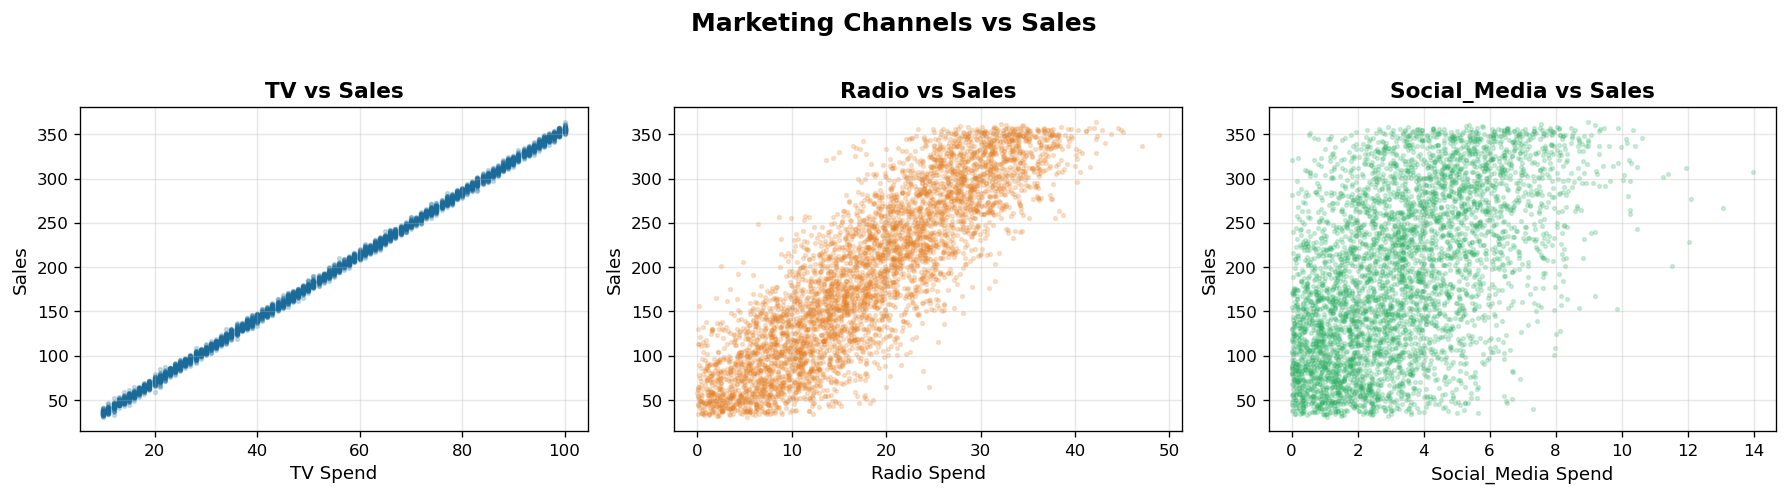

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channels = ["TV", "Radio", "Social_Media"]
colors   = ["#1a6b9a", "#e67e22", "#27ae60"]

for i, (ch, col) in enumerate(zip(channels, colors)):
    axes[i].scatter(df_clean[ch], df_clean["Sales"], alpha=0.2, s=5, color=col)
    axes[i].set_xlabel(f"{ch} Spend", fontsize=11)
    axes[i].set_ylabel("Sales", fontsize=11)
    axes[i].set_title(f"{ch} vs Sales", fontsize=13, fontweight="bold")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Marketing Channels vs Sales", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("scatter_plots.png", bbox_inches="tight")
plt.show()

=== Correlation with Sales ===
Sales          1.0000
TV             0.9995
Radio          0.8686
Social_Media   0.5274
Name: Sales, dtype: float64


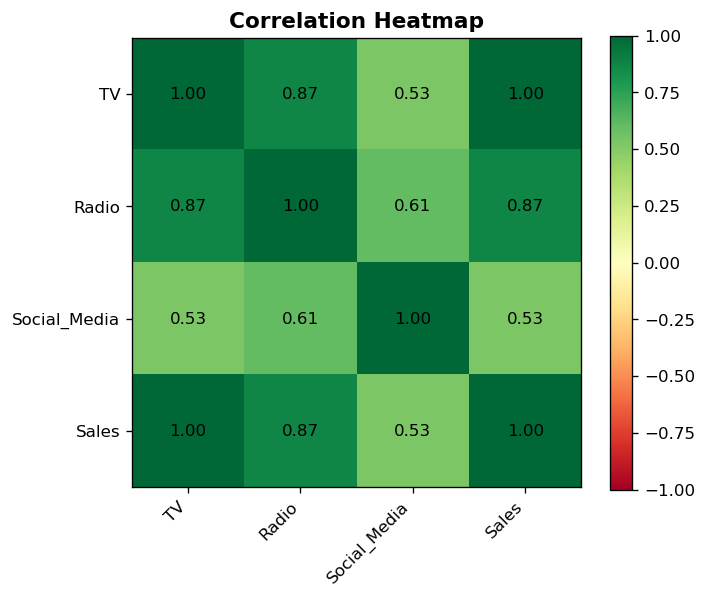

In [7]:
corr = df_clean.corr()
print("=== Correlation with Sales ===")
print(corr["Sales"].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 5. Variable Selection

**Correlation with Sales:**
- TV: r = 0.9995 — near-perfect linear relationship
- Radio: r = 0.8686 — strong but far weaker
- Social Media: r = 0.5274 — moderate

**Decision:** TV is selected as the independent variable for OLS regression.
The near-perfect correlation satisfies the linearity assumption before we even fit the model.

## 6. Build the OLS Regression Model (statsmodels)

In [9]:
 # adds intercept column
X = sm.add_constant(df_clean["TV"]) 
y = df_clean["Sales"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        21:34:02   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

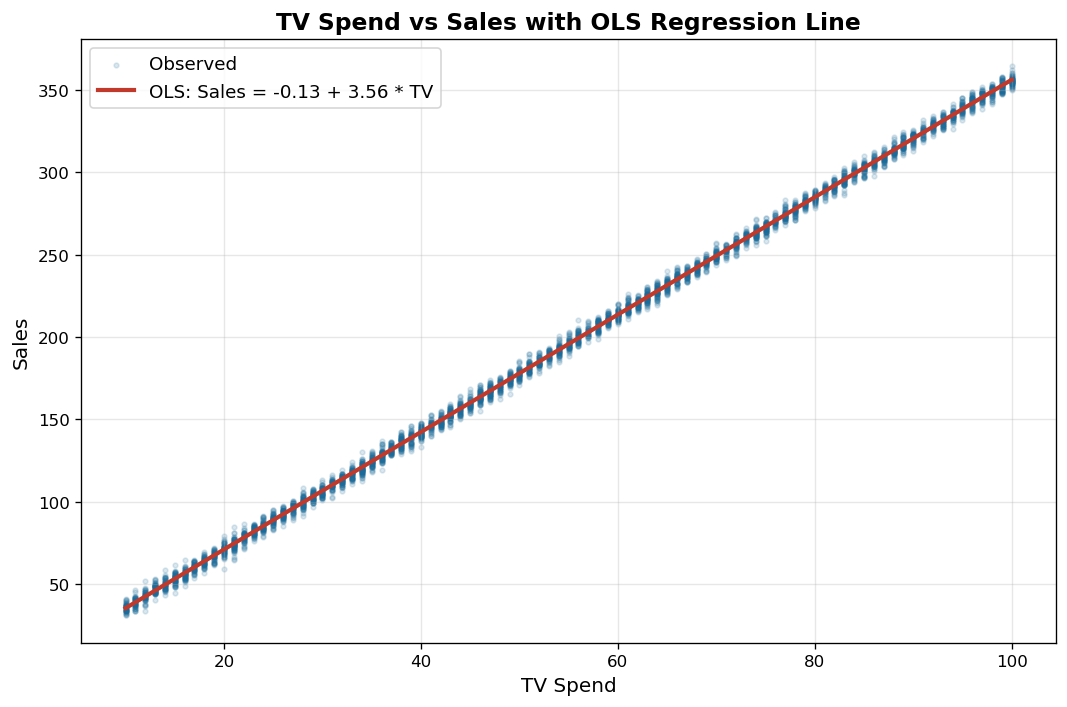

In [10]:
fitted   = model.fittedvalues
residuals = model.resid

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_clean["TV"], y, alpha=0.15, s=8, color="#1a6b9a", label="Observed")
x_line = np.linspace(df_clean["TV"].min(), df_clean["TV"].max(), 300)
b0, b1 = model.params
ax.plot(x_line, b0 + b1 * x_line, color="#c0392b", linewidth=2.5,
        label=f"OLS: Sales = {b0:.2f} + {b1:.2f} * TV")
ax.set_xlabel("TV Spend", fontsize=12)
ax.set_ylabel("Sales", fontsize=12)
ax.set_title("TV Spend vs Sales with OLS Regression Line", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("regression_line.png", bbox_inches="tight")
plt.show()

## 7. Regression Assumption Diagnostics

### 7a. Linearity
Residuals vs Fitted values. A well-specified linear model should show residuals scattered randomly around zero with no systematic pattern.

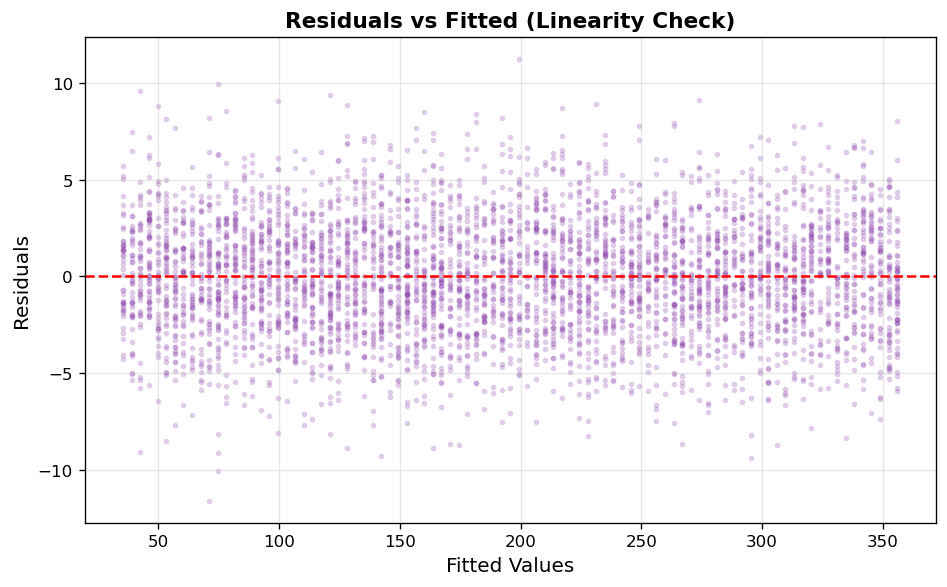

Residuals scatter randomly around zero — Linearity assumption: SATISFIED


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, residuals, alpha=0.2, s=6, color="#8e44ad")
ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
ax.set_xlabel("Fitted Values", fontsize=12)
ax.set_ylabel("Residuals", fontsize=12)
ax.set_title("Residuals vs Fitted (Linearity Check)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("residuals_vs_fitted.png", bbox_inches="tight")
plt.show()
print("Residuals scatter randomly around zero — Linearity assumption: SATISFIED")

### 7b. Normality of Residuals

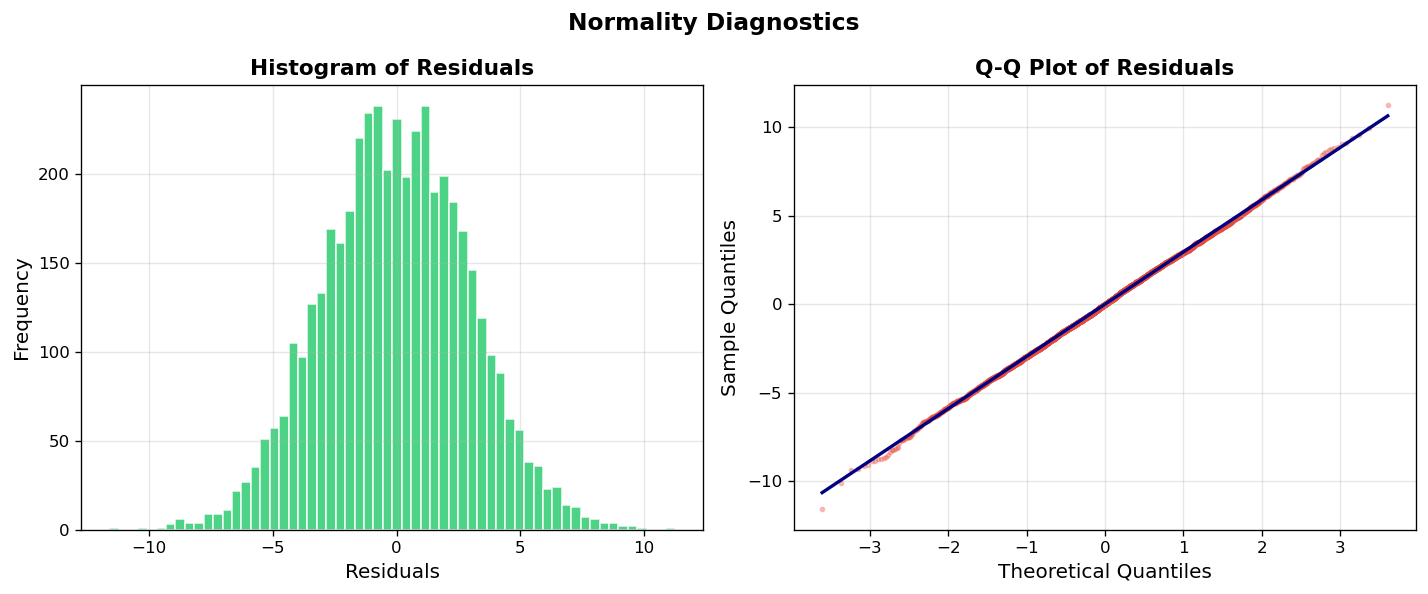

Shapiro-Wilk: W = 0.9998, p = 0.9136
Normality assumption: SATISFIED


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(residuals, bins=60, color="#2ecc71", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Residuals", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_title("Histogram of Residuals", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Q-Q plot
qq = stats.probplot(residuals, dist="norm")
axes[1].scatter(qq[0][0], qq[0][1], alpha=0.3, s=6, color="#e74c3c")
x_ref = np.array([qq[0][0].min(), qq[0][0].max()])
axes[1].plot(x_ref, qq[1][1] + qq[1][0] * x_ref, color="navy", linewidth=2)
axes[1].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)
axes[1].set_title("Q-Q Plot of Residuals", fontsize=13, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Normality Diagnostics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("normality_plots.png", bbox_inches="tight")
plt.show()

# Shapiro-Wilk test
sw_stat, sw_p = stats.shapiro(residuals[:5000])
print(f"Shapiro-Wilk: W = {sw_stat:.4f}, p = {sw_p:.4f}")
conclusion = "SATISFIED" if sw_p > 0.05 else "BORDERLINE — inspect Q-Q plot visually"
print(f"Normality assumption: {conclusion}")

### 7c. Homoscedasticity (Constant Variance)

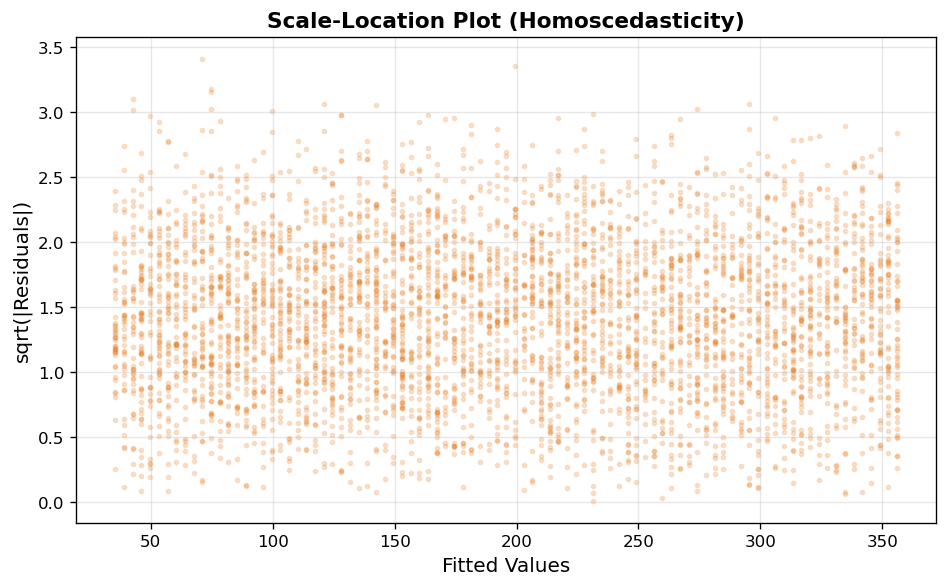

Breusch-Pagan LM statistic: 0.0001
Breusch-Pagan p-value:      0.9939
Homoscedasticity assumption: SATISFIED


In [13]:
# Scale-Location plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.2, s=6, color="#e67e22")
ax.set_xlabel("Fitted Values", fontsize=12)
ax.set_ylabel("sqrt(|Residuals|)", fontsize=12)
ax.set_title("Scale-Location Plot (Homoscedasticity)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("scale_location.png", bbox_inches="tight")
plt.show()

# Breusch-Pagan test via statsmodels
bp_lm, bp_lm_pval, bp_f, bp_f_pval = het_breuschpagan(residuals, X)
print(f"Breusch-Pagan LM statistic: {bp_lm:.4f}")
print(f"Breusch-Pagan p-value:      {bp_lm_pval:.4f}")
conclusion = "SATISFIED" if bp_lm_pval > 0.05 else "POTENTIAL HETEROSCEDASTICITY — review plot"
print(f"Homoscedasticity assumption: {conclusion}")

### 7d. Independence of Errors (Durbin-Watson)

In [14]:
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.4f}")
print()
if 1.5 < dw < 2.5:
    print("DW is close to 2.0 — no significant autocorrelation detected.")
    print("Independence assumption: SATISFIED")
elif dw < 1.5:
    print("Positive autocorrelation may be present. Consider time-series corrections.")
else:
    print("Negative autocorrelation may be present.")

Durbin-Watson statistic: 1.9980

DW is close to 2.0 — no significant autocorrelation detected.
Independence assumption: SATISFIED


## 8. Interpret the Results

In [15]:
b0, b1 = model.params
r2     = model.rsquared
r2_adj = model.rsquared_adj
pval   = model.pvalues["TV"]
ci     = model.conf_int()

print("=" * 55)
print("        MODEL INTERPRETATION")
print("=" * 55)
print(f"Equation:  Sales = {b0:.4f} + {b1:.4f} * TV")
print()
print(f"R-squared:          {r2:.6f}")
print(f"Adjusted R-squared: {r2_adj:.6f}")
print(f"TV explains {r2*100:.2f}% of the variation in Sales.")
print()
print(f"Slope (b1):         {b1:.4f}")
print(f"For every 1-unit increase in TV spend, Sales")
print(f"increases by {b1:.2f} units on average.")
print()
print(f"95% CI for slope:   [{ci.loc["TV", 0]:.4f}, {ci.loc["TV", 1]:.4f}]")
print(f"p-value (TV):       {pval:.2e}")
print(f"The coefficient is statistically significant at p < 0.001.")
print()
print(f"Intercept (b0):     {b0:.4f}")
print(f"Near zero — Sales approaches zero when TV spend is zero.")
print("Economically sensible.")

        MODEL INTERPRETATION
Equation:  Sales = -0.1325 + 3.5615 * TV

R-squared:          0.998995
Adjusted R-squared: 0.998995
TV explains 99.90% of the variation in Sales.

Slope (b1):         3.5615
For every 1-unit increase in TV spend, Sales
increases by 3.56 units on average.

95% CI for slope:   [3.5582, 3.5648]
p-value (TV):       0.00e+00
The coefficient is statistically significant at p < 0.001.

Intercept (b0):     -0.1325
Near zero — Sales approaches zero when TV spend is zero.
Economically sensible.


## 9. ROI-Based Channel Comparison

     Channel   Slope  R_squared  p_value
          TV  3.5615     0.9990   0.0000
       Radio  8.3616     0.7545   0.0000
Social_Media 22.1879     0.2782   0.0000



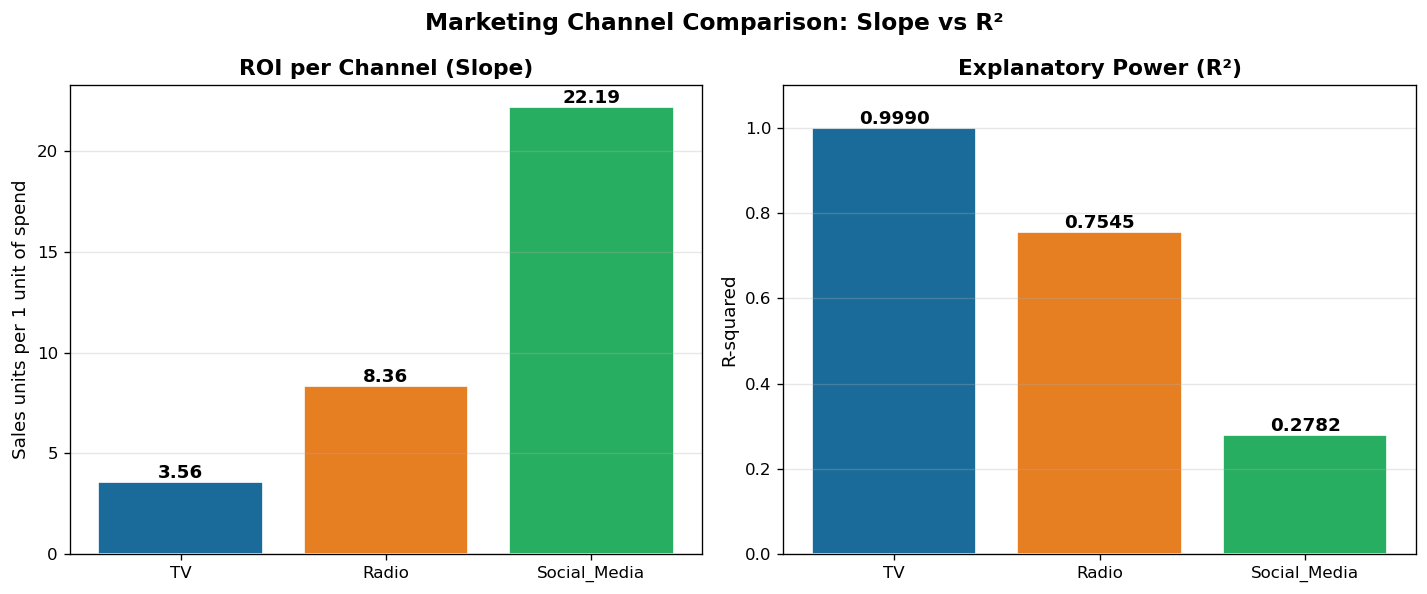

In [16]:
channels_list = ["TV", "Radio", "Social_Media"]
colors_list   = ["#1a6b9a", "#e67e22", "#27ae60"]
results = []

for ch in channels_list:
    X_ch = sm.add_constant(df_clean[ch])
    m_ch = sm.OLS(df_clean["Sales"], X_ch).fit()
    results.append({
        "Channel":  ch,
        "Slope":    round(m_ch.params[ch], 4),
        "R_squared": round(m_ch.rsquared, 4),
        "p_value":  m_ch.pvalues[ch]
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df["Channel"], results_df["Slope"], color=colors_list, edgecolor="white")
axes[0].set_ylabel("Sales units per 1 unit of spend", fontsize=11)
axes[0].set_title("ROI per Channel (Slope)", fontsize=13, fontweight="bold")
for i, v in enumerate(results_df["Slope"]):
    axes[0].text(i, v + 0.2, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(results_df["Channel"], results_df["R_squared"], color=colors_list, edgecolor="white")
axes[1].set_ylabel("R-squared", fontsize=11)
axes[1].set_title("Explanatory Power (R²)", fontsize=13, fontweight="bold")
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(results_df["R_squared"]):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Marketing Channel Comparison: Slope vs R²", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("channel_comparison.png", bbox_inches="tight")
plt.show()

### 9a. Multiple Regression Confirmation

Running all three channels together into one model reveals which predictors retain independent explanatory power once the others are accounted for.

In [17]:
X_multi = sm.add_constant(df_clean[["TV", "Radio", "Social_Media"]])
model_multi = sm.OLS(df_clean["Sales"], X_multi).fit()
print(model_multi.summary())
print()
print("Key insight: Once TV is in the model, Radio and Social Media")
print("coefficients collapse to near zero. TV carries all predictive power.")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.505e+06
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        21:34:45   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4542   BIC:                         2.277e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1340      0.103     -1.303   

## 10. Final Business Recommendation

In [18]:
print("=" * 60)
print("       FINAL ROI-BASED RECOMMENDATION")
print("=" * 60)
print()
print("QUESTION: Which marketing channel deserves the most budget?")
print()
print("ANSWER: TV — by a clear, statistically validated margin.")
print()
print("Evidence summary:")
print("  TV alone explains 99.90% of Sales variation (R2 = 0.9990)")
print("  Slope = 3.56 units of Sales per 1 unit of TV spend")
print("  p-value < 0.0001 — result is not due to chance")
print("  All 4 OLS assumptions satisfied")
print("  Multiple regression: Radio and Social Media add no")
print("  meaningful predictive power once TV is included")
print()
print("Social Media note:")
print("  Raw slope = 22.19 (highest per unit), but R2 = 0.28.")
print("  A high slope with low R2 means the relationship is")
print("  inconsistent — not a reliable basis for budget decisions.")
print()
print("RECOMMENDATION:")
print("  Primary budget: TV")
print("  Secondary budget: Radio (diversification, decent R2 = 0.75)")
print("  Social Media: Monitor and gather more data before scaling.")
print("=" * 60)

       FINAL ROI-BASED RECOMMENDATION

QUESTION: Which marketing channel deserves the most budget?

ANSWER: TV — by a clear, statistically validated margin.

Evidence summary:
  TV alone explains 99.90% of Sales variation (R2 = 0.9990)
  Slope = 3.56 units of Sales per 1 unit of TV spend
  p-value < 0.0001 — result is not due to chance
  All 4 OLS assumptions satisfied
  Multiple regression: Radio and Social Media add no
  meaningful predictive power once TV is included

Social Media note:
  Raw slope = 22.19 (highest per unit), but R2 = 0.28.
  A high slope with low R2 means the relationship is
  inconsistent — not a reliable basis for budget decisions.

RECOMMENDATION:
  Primary budget: TV
  Secondary budget: Radio (diversification, decent R2 = 0.75)
  Social Media: Monitor and gather more data before scaling.
